## Imports

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate
from sklearn.preprocessing import StandardScaler

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
from utils.tools import (
    extract_clean_segments,
    compute_lagged_correlations,
    find_dominant_lagged_pairs,
    print_dominant_pairs,
    plot_pearson_heatmap,
    report_correlation_distribution,
    classify_anomalies,
    summarize,
    collect_seg_stats,
    plot_threshold_sensitivity,
    preceding_normal_context,
    max_z_score,
    max_delta_rho_lagged,
    find_contiguous_segments,
    compute_univariate_intensity,
    plot_univariate_intensity_distribution
)

## Loading

In [2]:
df_cross = pd.read_csv("../../datasets/swat/SWAT.csv", low_memory=False)
df_cross['cols'] = df_cross['cols'].astype(str)
df_wide = df_cross.pivot(index='date', columns='cols', values='data').sort_index()

labels_series = df_wide['label'].astype(int)
features_df = df_wide.drop(columns=['label']).astype(np.float64)

N = len(features_df)
train_len = N // 2

In [3]:
normal_df = features_df.iloc[:train_len].copy()
attack_df = features_df.iloc[train_len:].copy()
attack_df['label'] = labels_series.iloc[train_len:].values
merged_df = features_df.copy()
merged_df['label'] = labels_series.values

print(f"Total length: {N}")
print(f"Anomalies in first half (should be 0 for SWAT): {(labels_series.iloc[:train_len] == 1).sum()}")
print(f"normal_df: {len(normal_df)}")
print(f"attack_df: {len(attack_df)} | anomalies: {(attack_df['label']==1).sum()}")

Total length: 944919
Anomalies in first half (should be 0 for SWAT): 0
normal_df: 472459
attack_df: 472460 | anomalies: 54621


## Basic info

In [4]:
merged_df.describe()

cols,AIT201,MV101,MV201,MV303,P201,P202,P204,AIT202,AIT203,AIT401,...,P501,P502,P601,P602,P603,PIT501,PIT502,PIT503,UV401,label
count,944919.000000,944919.000000,944919.000000,944919.000000,944919.000000,944919.0,944919.000000,944919.000000,944919.000000,944919.000000,...,944919.000000,944919.0,944919.0,944919.000000,944919.0,944919.000000,944919.000000,944919.000000,944919.000000,944919.000000
mean,238.316307,1.694267,1.720351,1.021706,1.057646,1.0,1.000059,8.455000,335.010187,136.186869,...,1.963072,1.0,1.0,1.008494,1.0,242.444917,1.104351,183.208231,1.963145,0.057805
std,36.250861,0.470349,0.457320,0.175340,0.233073,0.0,0.007698,0.124339,40.116361,41.453172,...,0.188585,0.0,0.0,0.091770,0.0,44.815360,0.332554,34.611861,0.188406,0.233374
min,168.033800,0.000000,0.000000,0.000000,1.000000,1.0,1.000000,6.000000,285.337100,0.000000,...,1.000000,1.0,1.0,1.000000,1.0,8.891951,0.000000,3.108177,1.000000,0.000000
25%,198.154300,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,8.363433,318.636300,148.803200,...,2.000000,1.0,1.0,1.000000,1.0,248.702300,0.961138,187.355800,2.000000,0.000000
50%,258.619600,2.000000,2.000000,1.000000,1.000000,1.0,1.000000,8.411177,329.274500,148.803200,...,2.000000,1.0,1.0,1.000000,1.0,250.640900,1.089290,189.182300,2.000000,0.000000
75%,265.572900,2.000000,2.000000,1.000000,1.000000,1.0,1.000000,8.553448,333.555500,148.808000,...,2.000000,1.0,1.0,1.000000,1.0,253.268400,1.265498,192.210300,2.000000,0.000000
max,272.526300,2.000000,2.000000,2.000000,2.000000,1.0,2.000000,8.988273,567.469900,148.856100,...,2.000000,1.0,1.0,2.000000,1.0,264.643700,3.668343,200.637600,2.000000,1.000000


In [5]:
merged_df.head()

cols,AIT201,MV101,MV201,MV303,P201,P202,P204,AIT202,AIT203,AIT401,...,P501,P502,P601,P602,P603,PIT501,PIT502,PIT503,UV401,label
date,,,,,,,,,,,,,,,,,,,,,
1,251.9226,1.0,1.0,1.0,1.0,1.0,1.0,8.313446,312.7916,0.0,...,1.0,1.0,1.0,1.0,1.0,9.100231,0.0,3.3485,1.0,0
2,251.9226,1.0,1.0,1.0,1.0,1.0,1.0,8.313446,312.7916,0.0,...,1.0,1.0,1.0,1.0,1.0,9.100231,0.0,3.3485,1.0,0
3,251.9226,1.0,1.0,1.0,1.0,1.0,1.0,8.313446,312.7916,0.0,...,1.0,1.0,1.0,1.0,1.0,9.100231,0.0,3.3485,1.0,0
4,251.9226,1.0,1.0,1.0,1.0,1.0,1.0,8.313446,312.7916,0.0,...,1.0,1.0,1.0,1.0,1.0,9.100231,0.0,3.3485,1.0,0
5,251.9226,1.0,1.0,1.0,1.0,1.0,1.0,8.313446,312.7916,0.0,...,1.0,1.0,1.0,1.0,1.0,9.100231,0.0,3.3485,1.0,0


In [6]:
attack_df.head()

cols,AIT201,MV101,MV201,MV303,P201,P202,P204,AIT202,AIT203,AIT401,...,P501,P502,P601,P602,P603,PIT501,PIT502,PIT503,UV401,label
date,,,,,,,,,,,,,,,,,,,,,
472460,261.7598,2.0,2.0,1.0,1.0,1.0,1.0,8.363433,331.838,148.7936,...,2.0,1.0,1.0,1.0,1.0,249.9039,1.201422,188.7176,2.0,0
472461,261.9200,2.0,2.0,1.0,1.0,1.0,1.0,8.362792,331.838,148.7936,...,2.0,1.0,1.0,1.0,1.0,249.9039,1.201422,188.7176,2.0,0
472462,261.9200,2.0,2.0,1.0,1.0,1.0,1.0,8.362792,331.838,148.7936,...,2.0,1.0,1.0,1.0,1.0,249.9039,1.201422,188.7176,2.0,0
472463,261.9200,2.0,2.0,1.0,1.0,1.0,1.0,8.362792,331.838,148.7936,...,2.0,1.0,1.0,1.0,1.0,249.8398,1.201422,188.7176,2.0,0
472464,261.9200,2.0,2.0,1.0,1.0,1.0,1.0,8.362792,331.838,148.7936,...,2.0,1.0,1.0,1.0,1.0,249.7917,1.057252,188.7176,2.0,0


In [7]:
normal_df.head()

cols,AIT201,MV101,MV201,MV303,P201,P202,P204,AIT202,AIT203,AIT401,...,P404,P501,P502,P601,P602,P603,PIT501,PIT502,PIT503,UV401
date,,,,,,,,,,,,,,,,,,,,,
1,251.9226,1.0,1.0,1.0,1.0,1.0,1.0,8.313446,312.7916,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,9.100231,0.0,3.3485,1.0
2,251.9226,1.0,1.0,1.0,1.0,1.0,1.0,8.313446,312.7916,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,9.100231,0.0,3.3485,1.0
3,251.9226,1.0,1.0,1.0,1.0,1.0,1.0,8.313446,312.7916,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,9.100231,0.0,3.3485,1.0
4,251.9226,1.0,1.0,1.0,1.0,1.0,1.0,8.313446,312.7916,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,9.100231,0.0,3.3485,1.0
5,251.9226,1.0,1.0,1.0,1.0,1.0,1.0,8.313446,312.7916,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,9.100231,0.0,3.3485,1.0


## Data exploration

In [8]:
# Check if there is any missing values in the training data
merged_df.isnull().sum()

cols
 AIT201    0
 MV101     0
 MV201     0
 MV303     0
 P201      0
 P202      0
 P204      0
AIT202     0
AIT203     0
AIT401     0
AIT402     0
AIT501     0
AIT502     0
AIT503     0
AIT504     0
DPIT301    0
FIT101     0
FIT201     0
FIT301     0
FIT401     0
FIT501     0
FIT502     0
FIT503     0
FIT504     0
FIT601     0
LIT101     0
LIT301     0
LIT401     0
MV301      0
MV302      0
MV304      0
P101       0
P102       0
P203       0
P205       0
P206       0
P301       0
P302       0
P401       0
P402       0
P403       0
P404       0
P501       0
P502       0
P601       0
P602       0
P603       0
PIT501     0
PIT502     0
PIT503     0
UV401      0
label      0
dtype: int64

In [9]:
# Check if timestep is constant.
time_diffs = merged_df.index.to_series().diff().dropna()
print(time_diffs.unique())

[1.]


In [10]:
print(merged_df.describe().loc[['mean', 'std', 'min', 'max']])

cols      AIT201     MV101     MV201     MV303      P201   P202      P204  \
mean  238.316307  1.694267  1.720351  1.021706  1.057646    1.0  1.000059   
std    36.250861  0.470349  0.457320  0.175340  0.233073    0.0  0.007698   
min   168.033800  0.000000  0.000000  0.000000  1.000000    1.0  1.000000   
max   272.526300  2.000000  2.000000  2.000000  2.000000    1.0  2.000000   

cols    AIT202      AIT203      AIT401  ...      P501  P502  P601      P602  \
mean  8.455000  335.010187  136.186869  ...  1.963072   1.0   1.0  1.008494   
std   0.124339   40.116361   41.453172  ...  0.188585   0.0   0.0  0.091770   
min   6.000000  285.337100    0.000000  ...  1.000000   1.0   1.0  1.000000   
max   8.988273  567.469900  148.856100  ...  2.000000   1.0   1.0  2.000000   

cols  P603      PIT501    PIT502      PIT503     UV401     label  
mean   1.0  242.444917  1.104351  183.208231  1.963145  0.057805  
std    0.0   44.815360  0.332554   34.611861  0.188406  0.233374  
min    1.0    8.8

In [11]:
discrete_channels = [2, 4, 9, 10, 11, 13, 15, 19, 20, 21, 22, 29, 30, 31, 32, 33, 42, 43, 48, 50]  # channels to exclude (from CrossAD code)
merged_df = merged_df.drop(merged_df.columns[discrete_channels], axis=1)
attack_df = attack_df.drop(attack_df.columns[discrete_channels], axis=1)
normal_df = normal_df.drop(normal_df.columns[discrete_channels], axis=1)

In [12]:
# Count number of entries for train, test, test labels
print("Number of merged_df entries:", len(merged_df))
print("Number of attack_df entries:", len(attack_df))
print("Number of normal_df labels entries:", len(normal_df))
# Print each but without na
print("Number of merged_df entries without NA:", len(merged_df.dropna()))
print("Number of attack_df entries without NA:", len(attack_df.dropna()))
print("Number of normal_df labels entries without NA:", len(normal_df.dropna()))

Number of merged_df entries: 944919
Number of attack_df entries: 472460
Number of normal_df labels entries: 472459
Number of merged_df entries without NA: 944919
Number of attack_df entries without NA: 472460
Number of normal_df labels entries without NA: 472459


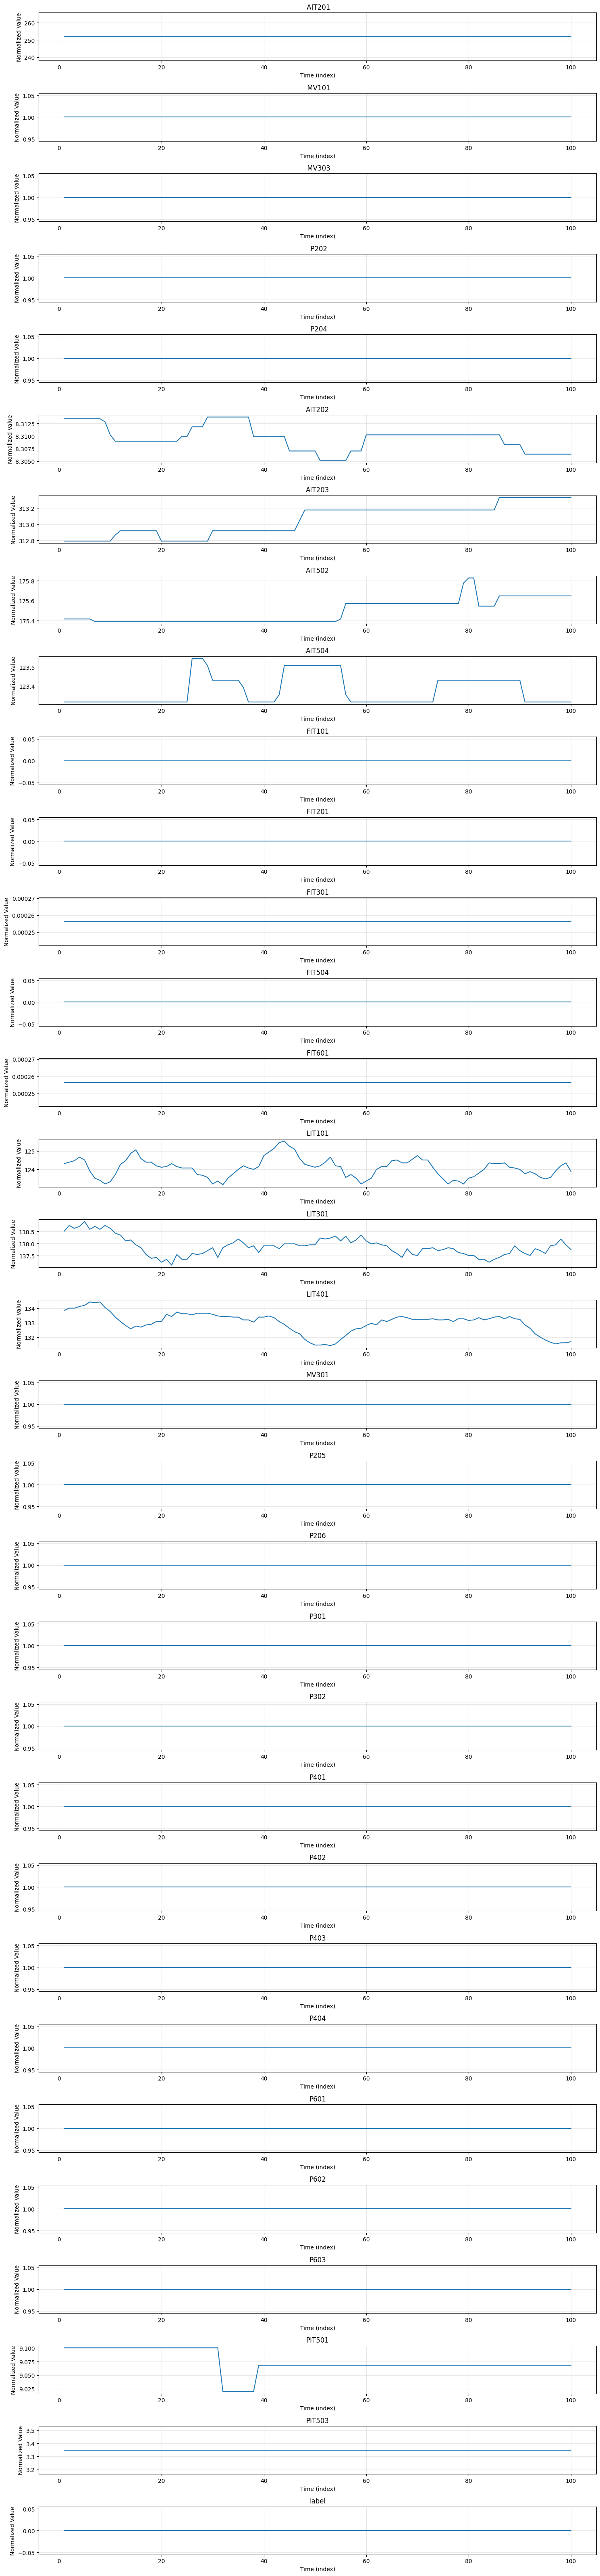

In [13]:
features_to_plot = [f for f in merged_df.columns if "timestamp" not in f.lower()]
num_features = len(features_to_plot)

plt.figure(figsize=(15, num_features * 2))

for i, feature in enumerate(features_to_plot):
    plt.subplot(num_features, 1, i + 1)
    plt.plot(merged_df[feature][:100])
    
    plt.title(f"{feature}")
    plt.xlabel('Time (index)')
    plt.ylabel('Normalized Value')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
normal_clean = normal_df.dropna()
attack_clean = attack_df.dropna()

print(f"Normal (train+val): {len(normal_clean)}")
print(f"Attack (test): {len(attack_clean)}")

train_end = int(len(normal_clean) * 0.8)
train_df = normal_clean.iloc[:train_end]
val_df = normal_clean.iloc[train_end:]

print(f"Train: {len(train_df)}")
print(f"Val: {len(val_df)}")
print(f"Test: {len(attack_clean)}")

Normal (train+val): 472459
Attack (test): 472460
Train: 377967
Val: 94492
Test: 472460


## Correlation Analysis

In [15]:
feature_cols = [c for c in normal_clean.columns if 'timestamp' not in c.lower() and 'normal' not in c.lower() and 'attack' not in c.lower()]
X_train = normal_clean[feature_cols].values.astype(np.float64)
feature_names = feature_cols
C = len(feature_names)

print(f"Train normal: {len(X_train)}, Channels: {C}")

Train normal: 472459, Channels: 31


/Users/marcp/.pyenv/versions/3.12.13/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/marcp/.pyenv/versions/3.12.13/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


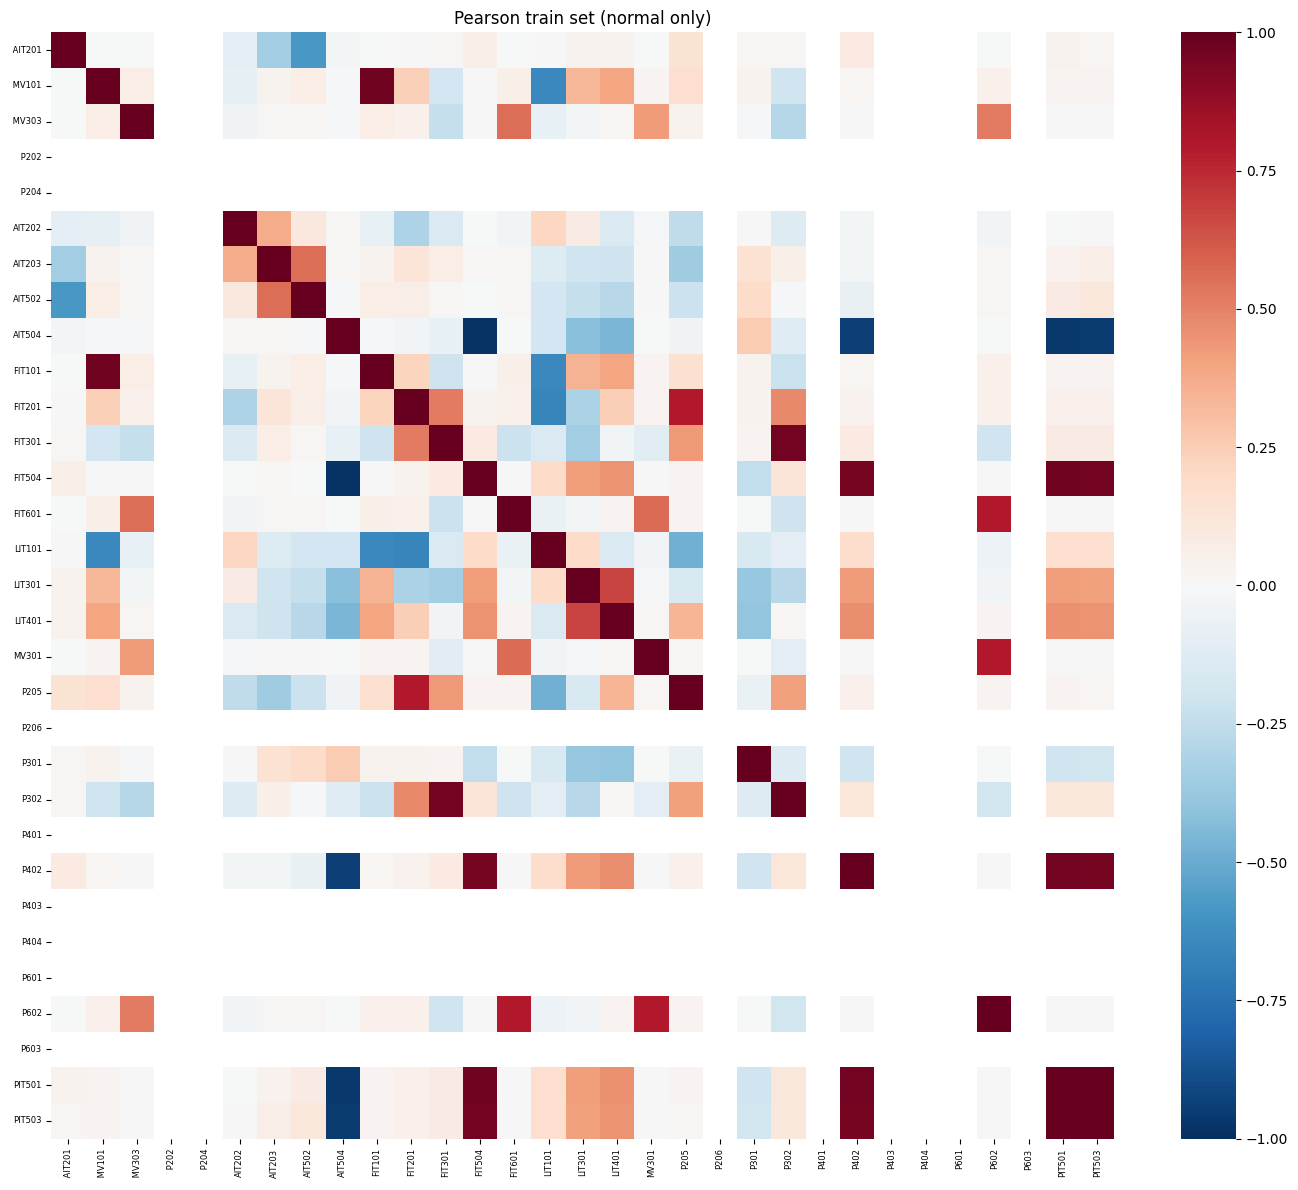

Total pairs: 253
  Pairs with |r| > 0.3: 53/253 (20.9%)
  Pairs with |r| > 0.5: 25/253 (9.9%)
  Pairs with |r| > 0.7: 15/253 (5.9%)


In [16]:
pearson_matrix = np.corrcoef(X_train, rowvar=False)

plot_pearson_heatmap(pearson_matrix, feature_names, title="Pearson train set (normal only)")
report_correlation_distribution(pearson_matrix)

Blank lines/columns are channels with a zero variance.

In [17]:
max_lag = 192

mask_clean_train = ~normal_df[feature_cols].isna().any(axis=1)
features_array = normal_df[feature_cols].values.astype(np.float64)
segments = extract_clean_segments(features_array, mask_clean_train.values, max_lag=max_lag)
if not segments:
    raise ValueError(f"No clean segment with length >= {2 * max_lag}.")

seg_lengths = list(map(len, segments))
print(f"Segments (L >= {2 * max_lag}): {len(segments)} | min={min(seg_lengths)}, max={max(seg_lengths)}, total={sum(seg_lengths)}")

lagged_corrs = compute_lagged_correlations(segments, max_lag=max_lag)

Segments (L >= 384): 1 | min=472459, max=472459, total=472459


Segments (Spearman): 100%|██████████| 1/1 [00:07<00:00,  7.79s/it]


In [18]:
pairs_info = find_dominant_lagged_pairs(lagged_corrs, max_lag=max_lag, threshold=0.5)
print("Pairs with dominant lagged correlation (|r(best_lag)| > 0.5 and > |r(0)|):")
print_dominant_pairs(pairs_info, feature_names=feature_names)

Pairs with dominant lagged correlation (|r(best_lag)| > 0.5 and > |r(0)|):
Total pairs: 231
  FIT504 - P402    : r(0)=+0.960  r(-109)=+0.993  [pearson]
  AIT504 - FIT504  : r(0)=-0.988  r(+17)=-0.989  [pearson]
  FIT504 - PIT501  : r(0)=+0.972  r(-96)=+0.986  [pearson]
  AIT504 - PIT501  : r(0)=-0.963  r(-71)=-0.984  [pearson]
  AIT504 - P402    : r(0)=-0.941  r(-90)=-0.983  [pearson]
  FIT301 - P302    : r(0)=+0.967  r(-7)=+0.983  [pearson]
  FIT504 - PIT503  : r(0)=+0.963  r(-97)=+0.980  [pearson]
  AIT504 - PIT503  : r(0)=-0.954  r(-74)=-0.979  [pearson]
  FIT601 - P602    : r(0)=+0.800  r(-7)=+0.977  [pearson]
   MV101 - FIT101  : r(0)=+0.971  r(+13)=+0.971  [pearson]
    P402 - PIT501  : r(0)=+0.968  r(+9)=+0.970  [pearson]
    P402 - PIT503  : r(0)=+0.959  r(+9)=+0.961  [pearson]
  FIT101 - LIT101  : r(0)=-0.644  r(-192)=-0.837  [pearson]
  FIT201 - LIT101  : r(0)=-0.662  r(+192)=-0.835  [pearson]
   MV101 - LIT101  : r(0)=-0.644  r(-192)=-0.825  [pearson]
  LIT301 - LIT401  : r(

## Anomaly Analysis

In [19]:
X_full = merged_df[feature_cols].values.astype(np.float64)
labels = merged_df['label'].values.astype(int)
N, C = X_full.shape

train_len = N // 2
normal_train_mask = (labels[:train_len] == 0)

scaler = StandardScaler().fit(X_full[:train_len][normal_train_mask])
X = scaler.transform(X_full[train_len:])
ev = labels[train_len:]

In [20]:
n_train = train_len
n_test = len(ev)
n_anom = int(ev.sum())
dim = X.shape[1]

print(f"Dimension: {dim}")
print(f"Train Size: {n_train}")
print(f"Test (labeled): {n_test}")
print(f"Anomaly Ratio (%): {100.0 * n_anom / n_test:.2f}")

Dimension: 31
Train Size: 472459
Test (labeled): 472460
Anomaly Ratio (%): 11.56


In [21]:
df_long, df_short = classify_anomalies(X, ev, pairs_info=pairs_info)
print(f"Anomalous segments: {len(df_long) + len(df_short)}")
summarize(df_long, df_short)

Anomalous segments: 35
Counts per method (long segments):
+----------------------+-----------+------------+--------+
| label                |   pearson |   spearman |   dcor |
|----------------------+-----------+------------+--------|
| UNIVARIATE           |         0 |          0 |      0 |
| BOTH                 |        35 |         35 |     35 |
| CROSS-CHANNEL        |         0 |          0 |      0 |
| UNDETECTED           |         0 |          0 |      0 |
| INSUFFICIENT_CONTEXT |         0 |          0 |      0 |
+----------------------+-----------+------------+--------+

Counts (short segments, < min_len points):
+----------------------+---------+
| label                |   count |
|----------------------+---------|
| UNIVARIATE           |       0 |
| UNDETECTED           |       0 |
| INSUFFICIENT_CONTEXT |       0 |
+----------------------+---------+


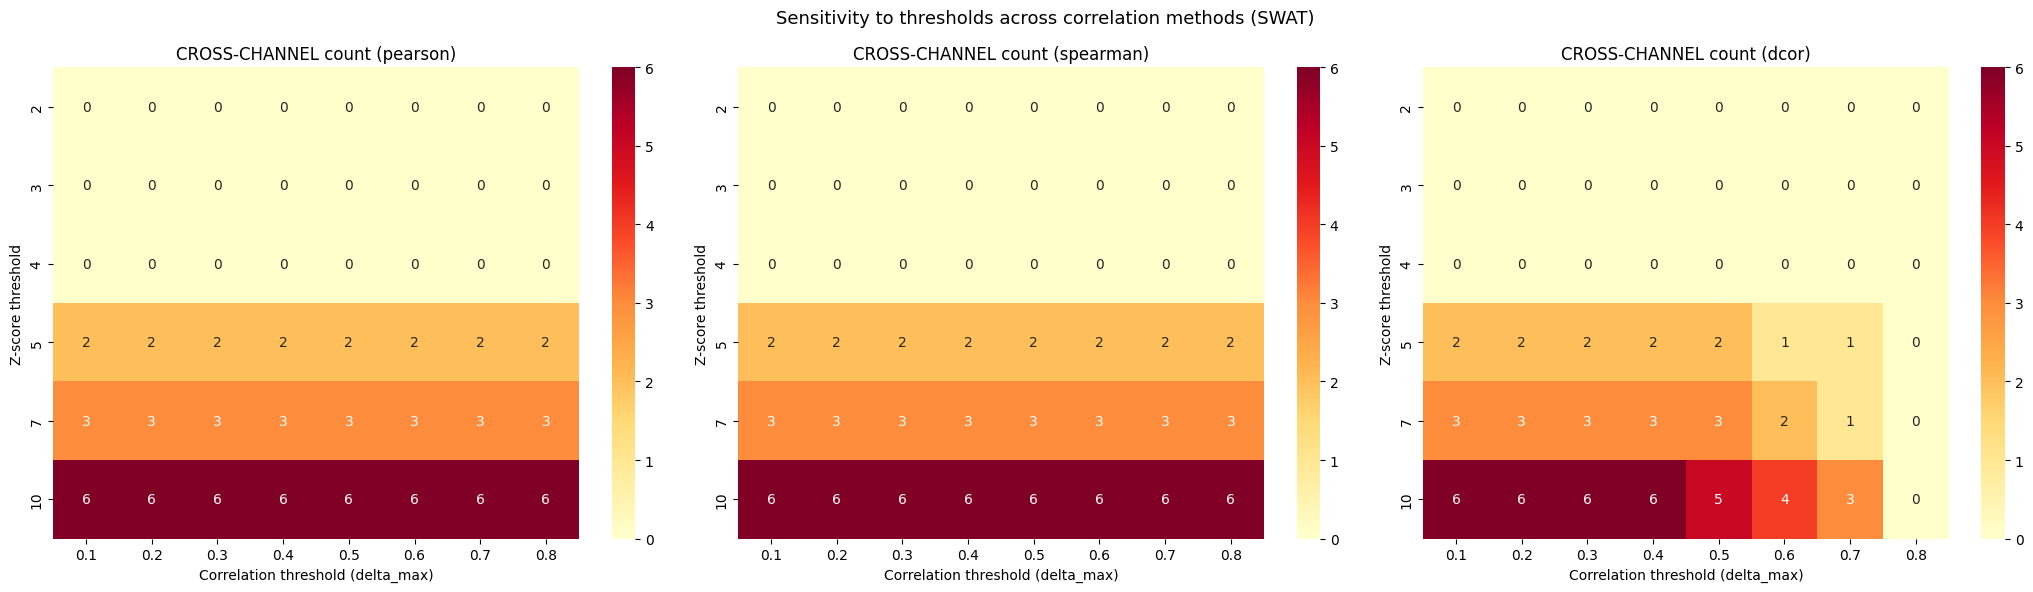

{'pearson': array([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [2, 2, 2, 2, 2, 2, 2, 2],
        [3, 3, 3, 3, 3, 3, 3, 3],
        [6, 6, 6, 6, 6, 6, 6, 6]]),
 'spearman': array([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [2, 2, 2, 2, 2, 2, 2, 2],
        [3, 3, 3, 3, 3, 3, 3, 3],
        [6, 6, 6, 6, 6, 6, 6, 6]]),
 'dcor': array([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [2, 2, 2, 2, 2, 1, 1, 0],
        [3, 3, 3, 3, 3, 2, 1, 0],
        [6, 6, 6, 6, 5, 4, 3, 0]])}

In [22]:
seg_stats = collect_seg_stats(X, ev, pairs_info=pairs_info)
plot_threshold_sensitivity(seg_stats, title="Sensitivity to thresholds across correlation methods (SWAT)")

In [23]:
normal_test = (ev == 0)
for s, e in find_contiguous_segments(ev):
    anom = X[s:e]
    anom = anom[~np.isnan(anom).any(axis=1)] if np.isnan(anom).any() else anom
    ctx = preceding_normal_context(s, X, normal_test)
    if ctx is None or len(anom) < 10:
        continue
    mz = max_z_score(anom, ctx)
    md = max_delta_rho_lagged(anom, ctx, pairs_info)
    if mz <= 10 and mz > 5 and (not np.isnan(md)) and md > 0.3:
        print(f"[{s},{e}) len={e-s} max_z={mz:.2f} delta={md:.3f}")

[29000,29390) len=390 max_z=9.79 delta=1.752
[96341,97062) len=721 max_z=7.94 delta=1.806
[138684,139079) len=395 max_z=6.02 delta=1.342
[460688,461089) len=401 max_z=7.12 delta=1.831


As expected, their z-score are easily detectable.

In [24]:
intensity_df, summary = compute_univariate_intensity(
    test_arrays=[X], label_arrays=[ev], names=['swat'],
)
print(tabulate(summary, headers='keys', tablefmt='psql', floatfmt='.3f', showindex=False))

+--------------+------------------+--------------------+-----------------+
|   n_segments |   mean_ratio_uni |   median_ratio_uni |   min_ratio_uni |
|--------------+------------------+--------------------+-----------------|
|       35.000 |            0.933 |              1.000 |           0.575 |
+--------------+------------------+--------------------+-----------------+


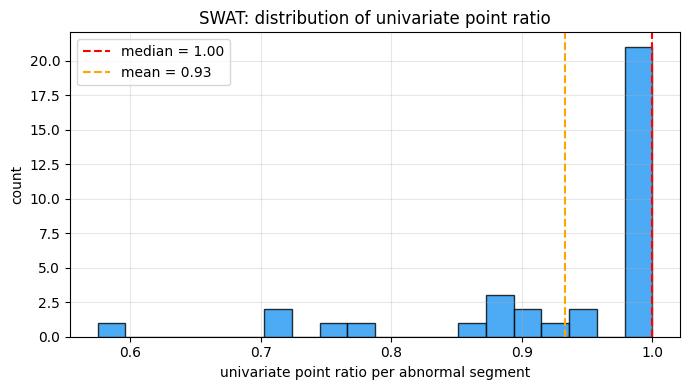

In [25]:
plot_univariate_intensity_distribution(intensity_df, 'SWAT')

Number of BOTH segments (union over pearson/spearman/dcor): 35
Anomalous points retained: 54621 / 54621 (100.0%)
+--------------+------------------+--------------------+-----------------+
|   n_segments |   mean_ratio_uni |   median_ratio_uni |   min_ratio_uni |
|--------------+------------------+--------------------+-----------------|
|       35.000 |            0.933 |              1.000 |           0.575 |
+--------------+------------------+--------------------+-----------------+


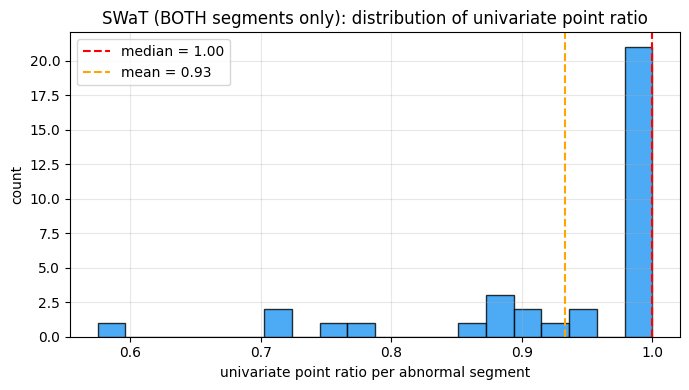

In [26]:
both_mask = (
    (df_long['lab_pearson'] == 'BOTH') |
    (df_long['lab_spearman'] == 'BOTH') |
    (df_long['lab_dcor'] == 'BOTH')
)
both_segments = df_long.loc[both_mask, ['start', 'end']].astype(int).values

ev_both = np.zeros_like(ev)
for s, e in both_segments:
    ev_both[s:e] = 1

print(f"Number of BOTH segments (union over pearson/spearman/dcor): {len(both_segments)}")
print(f"Anomalous points retained: {int(ev_both.sum())} / {int(ev.sum())} ({100.0 * ev_both.sum() / max(ev.sum(), 1):.1f}%)")

intensity_df_both, summary_both = compute_univariate_intensity(
    test_arrays=[X], label_arrays=[ev_both], names=['swat_both'],
)
print(tabulate(summary_both, headers='keys', tablefmt='psql', floatfmt='.3f', showindex=False))

plot_univariate_intensity_distribution(intensity_df_both, 'SWaT (BOTH segments only)')